In [ ]:
#Importing necessary libraries and modules.  Pandas is for data manipulation, matplotlib and seaborn for data visualization and sci-kit learn for filling missing values using KNN.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import matplotlib.ticker as ticker        #for customizing axis ticks while plotting graphs
import seaborn as sns

In [ ]:
#Using pandas.read_csv() function for importing data from car.csv file into df dataframe
df = pd.read_csv('EDA/car.csv')               

In [ ]:
#Extracting random 10 rows from df dataframe for inspection
df.sample(10)

,Name,Price,Used For,Transmisson,Colour,Make Year,Mileage,Engine (CC),Fuel,Kilometer Run,Waranty,Types
594,Tata intra V20 on sale (Tata),"रू. 14,50,000",2 years,Manual - 2WD,blue,2020,12,1396,Diesel,28000,NaN,NaN
518,Hyundai Tucson ix35 4WD (Hyundai),"रू. 36,50,000",personal,Manual4WD,orange,2011,12-Oct,1995cc,Diesel,87000,No Warranty,NaN
512,Suzuki Balena (2017) For Sale! (Maruti Suzuki),"रू. 24,00,000",NaN,Manual2WD,NaN,2017,NaN,NaN,Petrol,NaN,NaN,NaN
673,Maruti Delivery Van (Maruti Suzuki),"रू. 5,05,000",Household use,Manual2WD,White,2015,15km/ltr,800,Petrol,52500,NaN,NaN
405,skoda laura 2011 (Skoda),"रू. 15,25,000",NaN,Manual - 2WD,black,2011,10,1896,Diesel,70000,NaN,NaN
414,Zen Stailo Vxi 2010 (Maruti Suzuki),"रू. 10,25,000",NaN,Manual - 2WD,goldenó,2010,NaN,996,Petrol,51000,NaN,NaN
480,I10 on sale (Hyundai),"रू. 16,00,000",NaN,Manual2WD,Gray,2012,14-15,1100,Petrol,33000,NaN,NaN
268,Ecosport Signature 2018(9851008482) (Ford),"रू. 35,50,000",NaN,Manual - 2WD,Blue,2018,NaN,1500,Petrol,NaN,NaN,NaN
613,Full fresh condition zyotee mini JEEP on sale ...,"रू. 9,95,000",12 years,Manual2WD,Black,2010,14,1300,Petrol,48000,NaN,NaN
590,scorpio m2 di crd (Mahindra),"रू. 11,85,000",NaN,Auto - 2WD,black,2006,16,2523,Diesel,NaN,NaN,NaN


In [ ]:
#Checking the dimension of the df dataframe. It shows that the dataframe contains 848 rows and 12 columns
df.shape

(848, 12)

In [ ]:
#Extracting the summary of the dataframe. It shows the non null count and data type stored in each rows and columns of the dataframe.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 848 entries, 0 to 847
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           848 non-null    object 
 1   Price          848 non-null    object 
 2   Used For       357 non-null    object 
 3   Transmisson    848 non-null    object 
 4   Colour         766 non-null    object 
 5   Make Year      848 non-null    object 
 6   Mileage        458 non-null    object 
 7   Engine (CC)    741 non-null    object 
 8   Fuel           848 non-null    object 
 9   Kilometer Run  706 non-null    object 
 10  Waranty        209 non-null    object 
 11  Types          0 non-null      float64
dtypes: float64(1), object(11)
memory usage: 79.6+ KB


In [ ]:
#CHecking the missing values in the dataframe and counting the number of null values using sum()
df.isnull().sum()

,0
Name,0
Price,0
Used For,491
Transmisson,0
Colour,82
Make Year,0
Mileage,390
Engine (CC),107
Fuel,0
Kilometer Run,142


In [ ]:
#Counting the number of unique values in the dataframe by excluding NaN values
df.nunique()

,0
Name,832
Price,316
Used For,183
Transmisson,10
Colour,182
Make Year,40
Mileage,87
Engine (CC),140
Fuel,4
Kilometer Run,247


In [ ]:
#Renaming each columns of the dataframe for ease and uniformity
df = df.rename(columns={
    'Name': 'name',
    'Price': 'price',
    'Used For': 'used_for',
    'Transmisson': 'transmission',
    'Colour': 'colour',
    'Make Year': 'make_year',
    'Mileage': 'mileage',
    'Engine (CC)': 'engine_cc',
    'Fuel': 'fuel',
    'Kilometer Run': 'km_run',
    'Waranty': 'warranty',
    'Types': 'types'
})

In [ ]:
#Identifying duplicate values in the dataframe and calculating the total number of duplicate values
df.duplicated().sum()

np.int64(1)

In [ ]:
#Dropping the duplicate rows in the dataframe that has the same name. Only the first occurence is kept and other duplicates are dropped

df = df.drop_duplicates(subset='name', keep='first')

In [ ]:
#Deleting unnecessary columns to reduce the size of the dataset. The column 'types' is dropped as it is empty, 'used_for'
#can be guessed from the make_year column and warranty is not taken into consideration as the dataset mostly contain second hand automobiles.

df = df.drop(columns=['types', 'used_for'])
df = df.drop('warranty', axis= 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 832 entries, 0 to 847
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          832 non-null    object
 1   price         832 non-null    object
 2   transmission  832 non-null    object
 3   colour        751 non-null    object
 4   make_year     832 non-null    object
 5   mileage       452 non-null    object
 6   engine_cc     727 non-null    object
 7   fuel          832 non-null    object
 8   km_run        692 non-null    object
dtypes: object(9)
memory usage: 65.0+ KB


In [ ]:
#Creating a function that removes the 'रू.' and ',' from the price column. It also retrieves the first amount when there are two prices for the same car.
def new_price(price_str):
  cleaned_str = price_str.replace('रू.','').replace(',','')
  parts = cleaned_str.strip().split()
  if parts:
    return int(parts[0])


df['price'] = df['price'].apply(new_price).astype(int)          #Converting the price column to int

In [ ]:
#The brand names of the car are listed in the parenthesis in the name column.
#Extracting the brand names using regular expression and storing it into a separate column named brand in the dataframe.
df['brand'] = df['name'].str.extract(r'\((.*?)\)')

In [ ]:
#Converting the contents of columns with text into lowercase for uniformity as it helps to process them easily. Removing '-' and ' ' from the transmission column
df['name'] = df['name'].str.lower()
df['colour'] = df['colour'].str.lower()
df['fuel'] = df['fuel'].str.lower()
df['brand'] = df['brand'].str.lower()
df['transmission'] = df['transmission'].str.lower()
df['transmission'] = df['transmission'].str.replace('-', '')
df['transmission'] = df['transmission'].str.replace(' ', '')

In [ ]:
#Converting 'make_year', 'mileage', 'engine_cc', 'km_run' columns to numeric values and extracting the numbers only
df['make_year'] = pd.to_numeric(df['make_year'].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')

num = df['mileage'].astype(str).str.findall(r'\d+').str[0]
df['mileage'] = pd.to_numeric(num, errors='coerce')

capacity= df['engine_cc'].astype(str).str.findall(r'\d+').str[0]
df['engine_cc'] = pd.to_numeric(capacity, errors='coerce')

km= df['km_run'].astype(str).str.findall(r'\d+').str[0]
df['km_run'] = pd.to_numeric(km, errors='coerce')

In [ ]:
df.loc[df['mileage'] < 50, 'mileage'] = np.nan

In [ ]:
#Replacing the empty spaces in the numeric columns with values using KNN imputation method.
numeric_cols = df.select_dtypes(include=np.number).columns

imputer = KNNImputer(n_neighbors=3)

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])


In [ ]:
#Converting all the numeric columns into integer
df['price'] = df['price'].astype(int)
df['make_year'] = df['make_year'].astype(int)
df['mileage'] = df['mileage'].astype(int)
df['engine_cc'] = df['engine_cc'].astype(int)
df['km_run'] = df['km_run'].astype(int)


In [ ]:
#Calculating the age of each car by subtracting make year of the car to the current year. It drops the rows if the make year is greater than current year or less than 1975.
#The car age is then stored in a separate column in the dataframe
current_year = 2025
rows_to_drop = df[(df['make_year'] > current_year) | (df['make_year'] < 1975)].index
df = df.drop(rows_to_drop)
df['car_age'] = current_year - df['make_year']

**1. Correlation Matrix**

The correlation matrix plot shows how the different car features relate to each other. Values close to 1 mean the features increase together, and values close to -1 mean they move in opposite directions. Most of the features don't have strong relationships, but there are a few noticeable ones:


*   Price has a small positive link with engine size and make year.
*   Car age and make year are strongly negatively related, which makes sense because older cars have lower make_year values.






Text(0.5, 1.0, 'CORRELATION MATRIX')

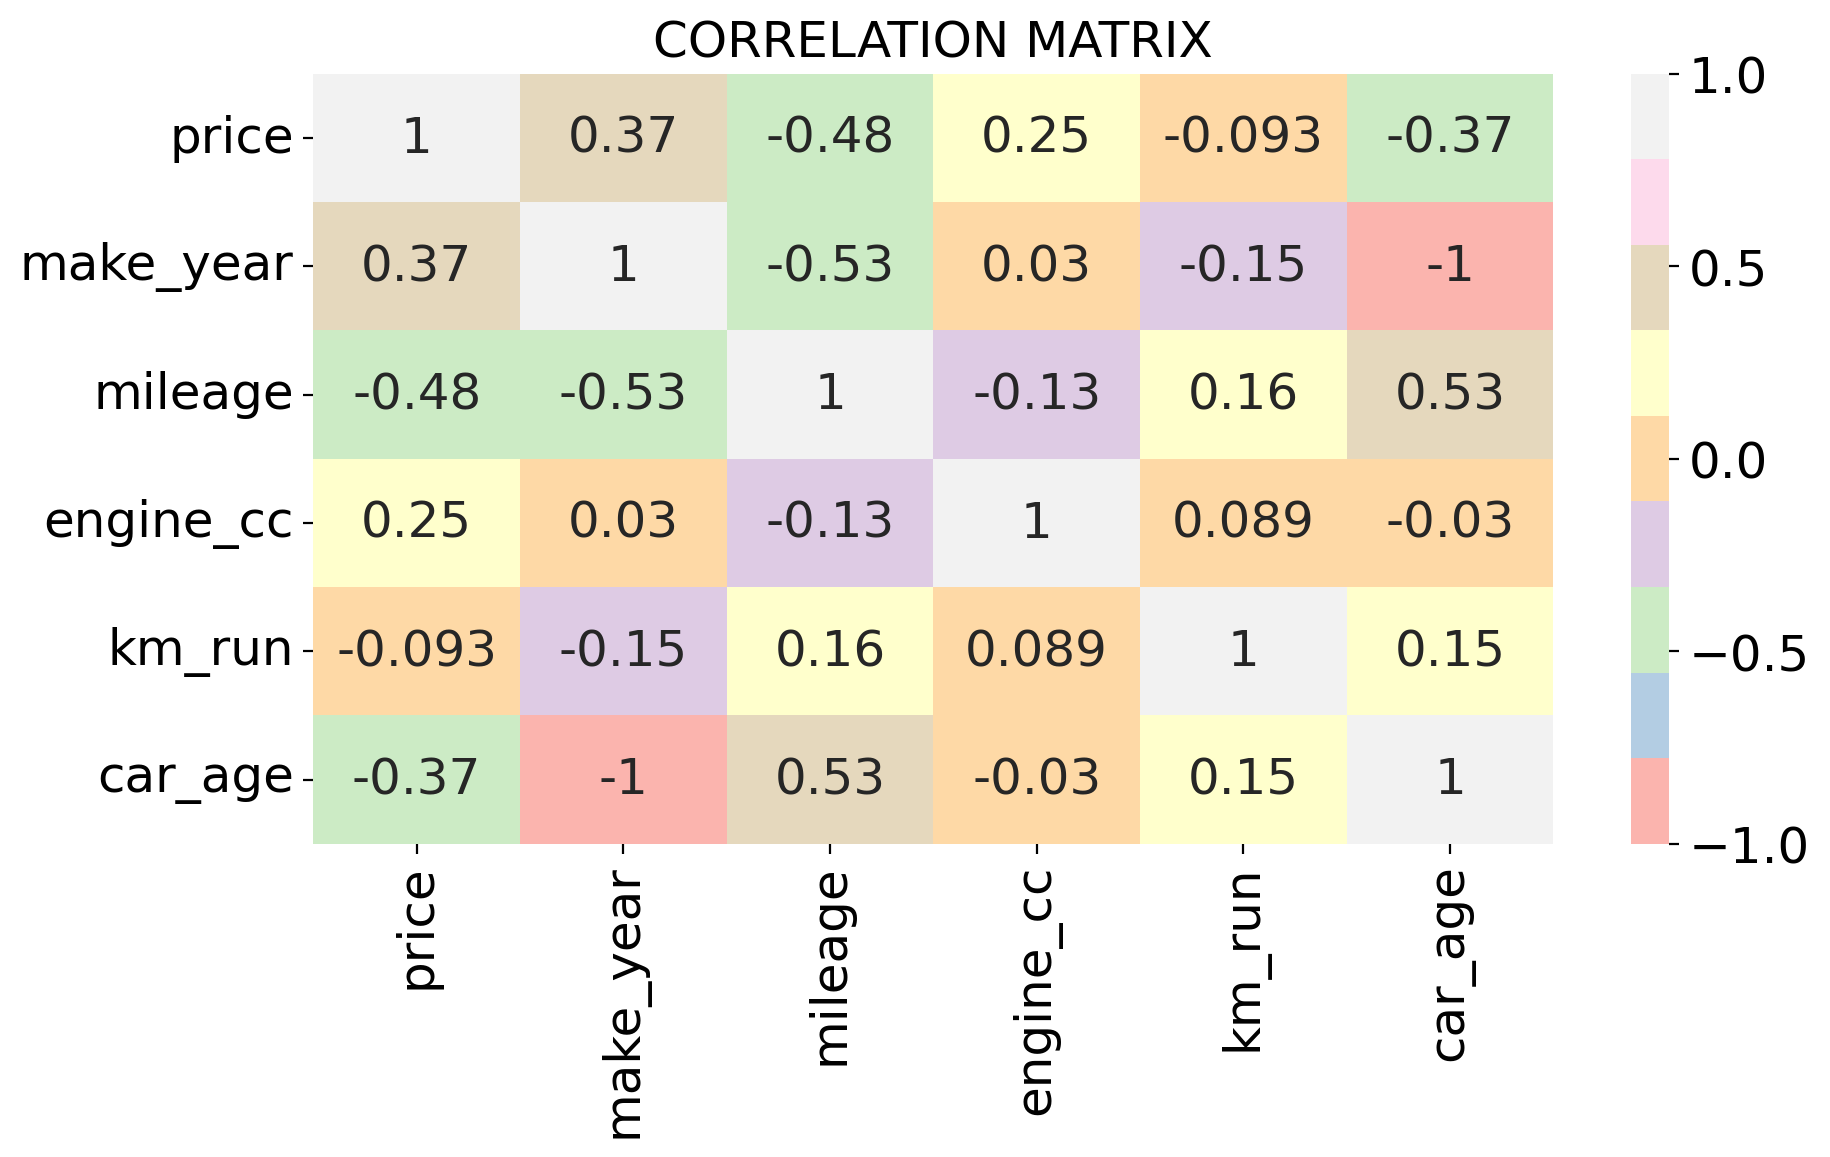

In [ ]:
#Showing the dependencies of all the numeric columns with each other using heatmap.
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap= 'Pastel1')
plt.title('CORRELATION MATRIX', fontdict={'fontsize': 18})

**2. Popular Transmission Type**

The pie chart shows how many cars fall under each transmission category. Manual is by far the most common type in the dataset, while the other types like auto and powersteering appear much less often. This shows cars with manual transmission types dominate the dataset.

In [ ]:
#Sorting cars based on the transmission type
def sort_transmission(trans_type):
  if 'manual' in trans_type:
    return 'manual'
  elif 'auto' in trans_type:
    return 'auto'
  elif 'powersteering' in trans_type:
    return 'powersteering'

df['transmission'] = df['transmission'].apply(sort_transmission)

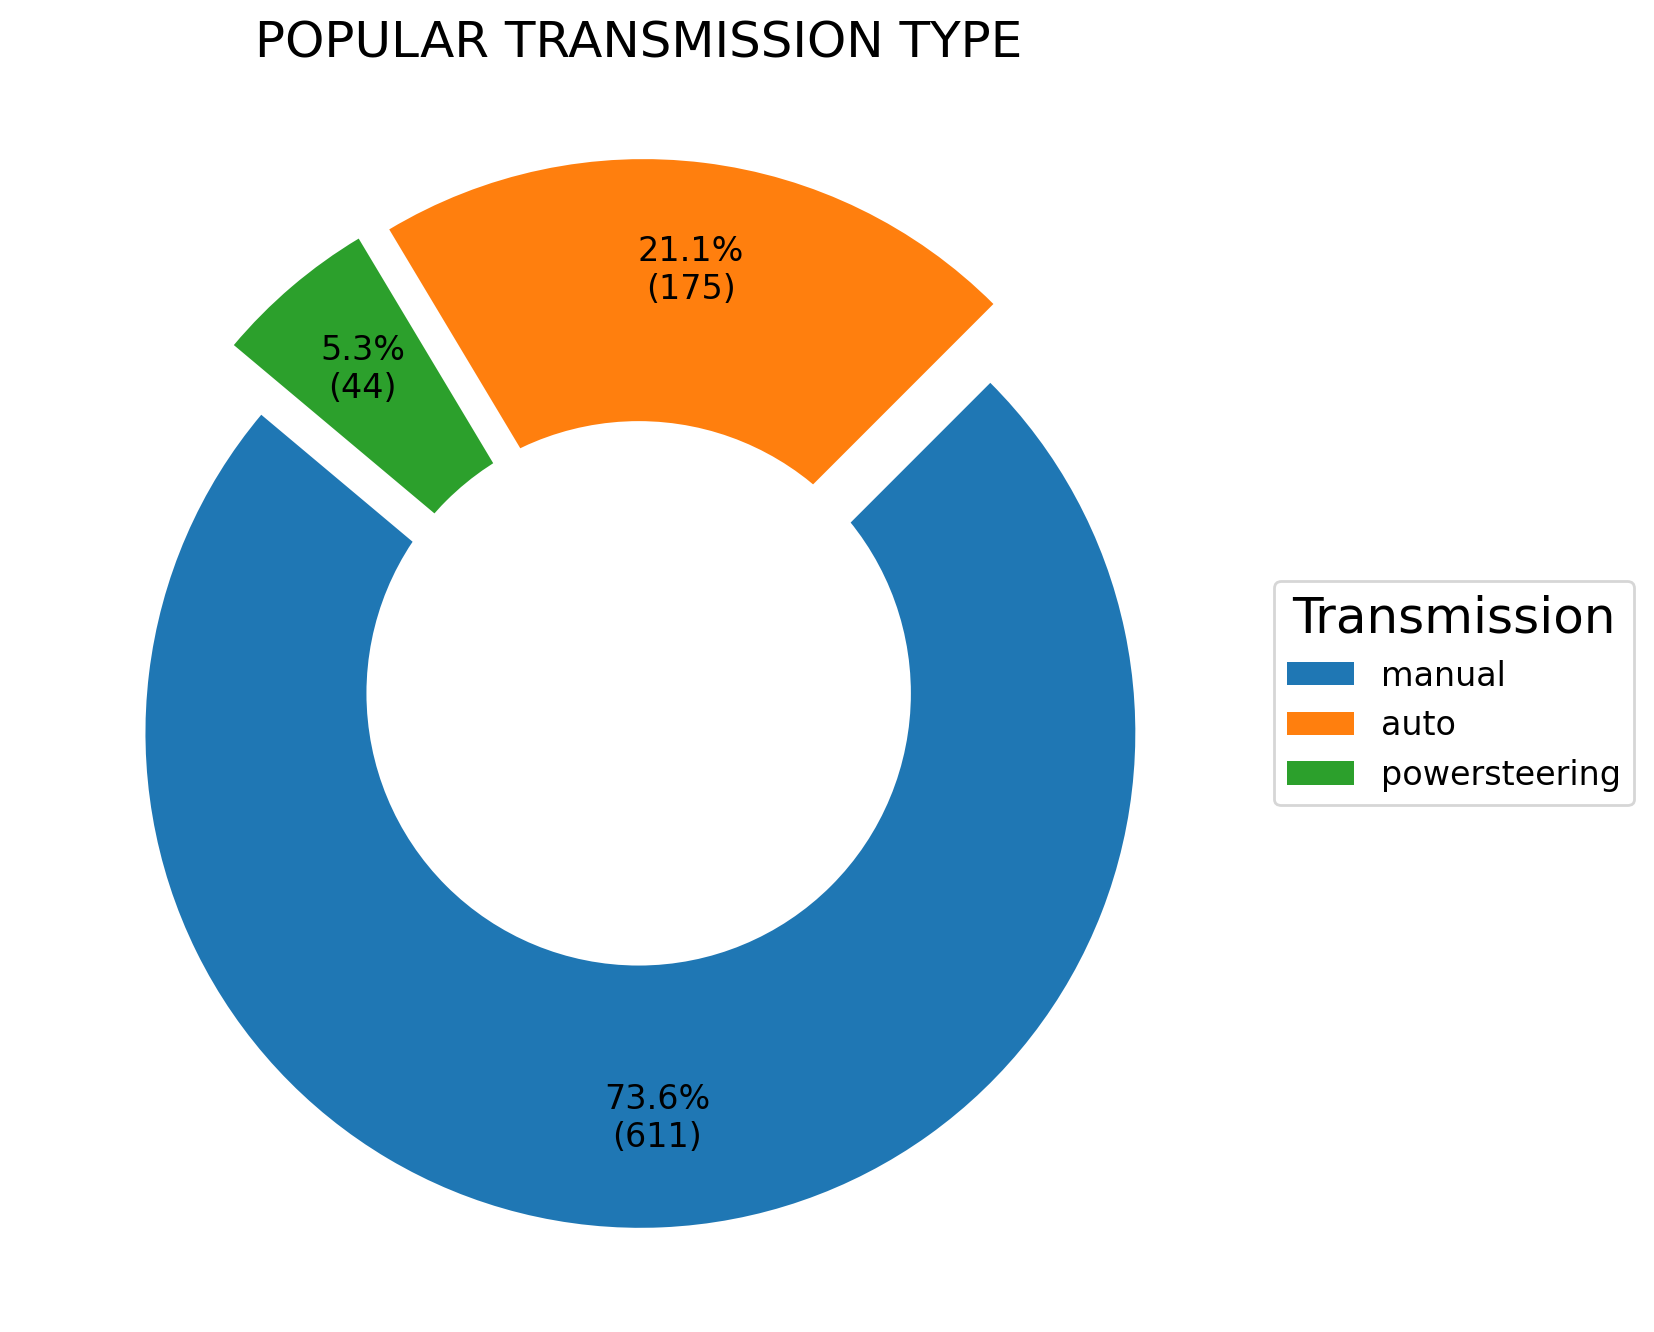

In [ ]:
counts = df['transmission'].value_counts()
labels = counts.index
sizes = counts.values

explode = [0.08] * len(sizes)
plt.figure(figsize=(10, 7))

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=None,
    explode=explode,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100 * sizes.sum()))})',
    pctdistance=0.78,
    startangle=140,
    textprops={'fontsize': 12}
)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('POPULAR TRANSMISSION TYPE', fontsize=18)

plt.legend(
    wedges,
    labels,
    title="Transmission",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12
)

plt.tight_layout()
plt.show()


**3. Fuel Type Distribution**

The bubble chart shows how many cars use each fuel type. Petrol cars make up the biggest portion of the dataset, followed by diesel. Electric and hybrid cars are present but in very small numbers.

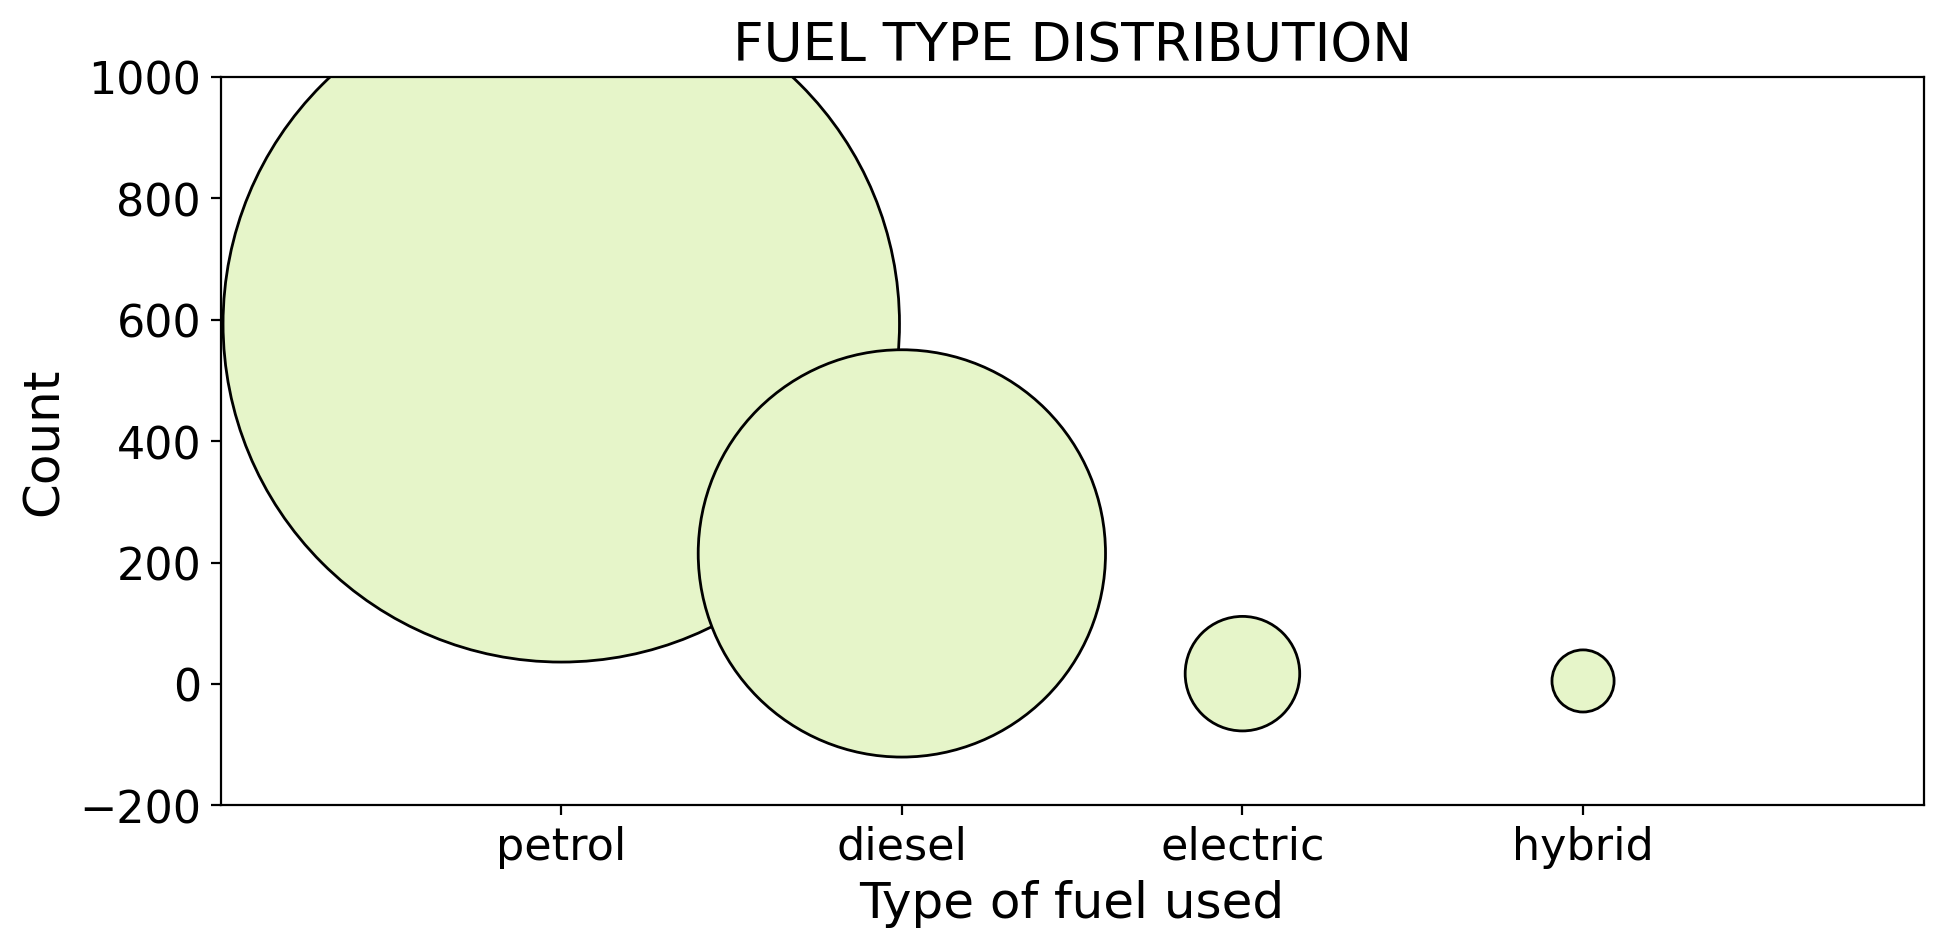

In [ ]:
#Showing the most commonly used fuel type
counts = df['fuel'].value_counts()
x = np.arange(len(counts.index))
y = counts.values
labels = counts.index
sizes =y*100
plt.figure(figsize=(10,5))
plt.rcParams['font.size'] = 16
plt.scatter(x, y, s=sizes, color=plt.cm.Pastel2(0.6), edgecolors='black')
plt.xticks(x, labels)
plt.title("FUEL TYPE DISTRIBUTION")
plt.xlabel("Type of fuel used", fontdict={'fontsize': 18})
plt.ylabel("Count", fontdict={'fontsize': 18})
plt.xlim(-1, len(counts.index))
plt.ylim(-200, 1000)

plt.tight_layout()
plt.show()


In [ ]:
#Extracting alphabets only from brand column and filling nan with ''
alphabetic_rows = df['brand'].fillna('').str.isalpha()
df = df[alphabetic_rows]

**4. Top 10 Car Brands**

The bar chart shows the top 10 most listed car brands in the dataset.
Hyundai clearly dominates with the highest count, followed by Tata and Mahindra. The other brands like Toyota, Kia, Ford, Volkswagen, Nissan, Honda, and Chevrolet appear in much smaller numbers.

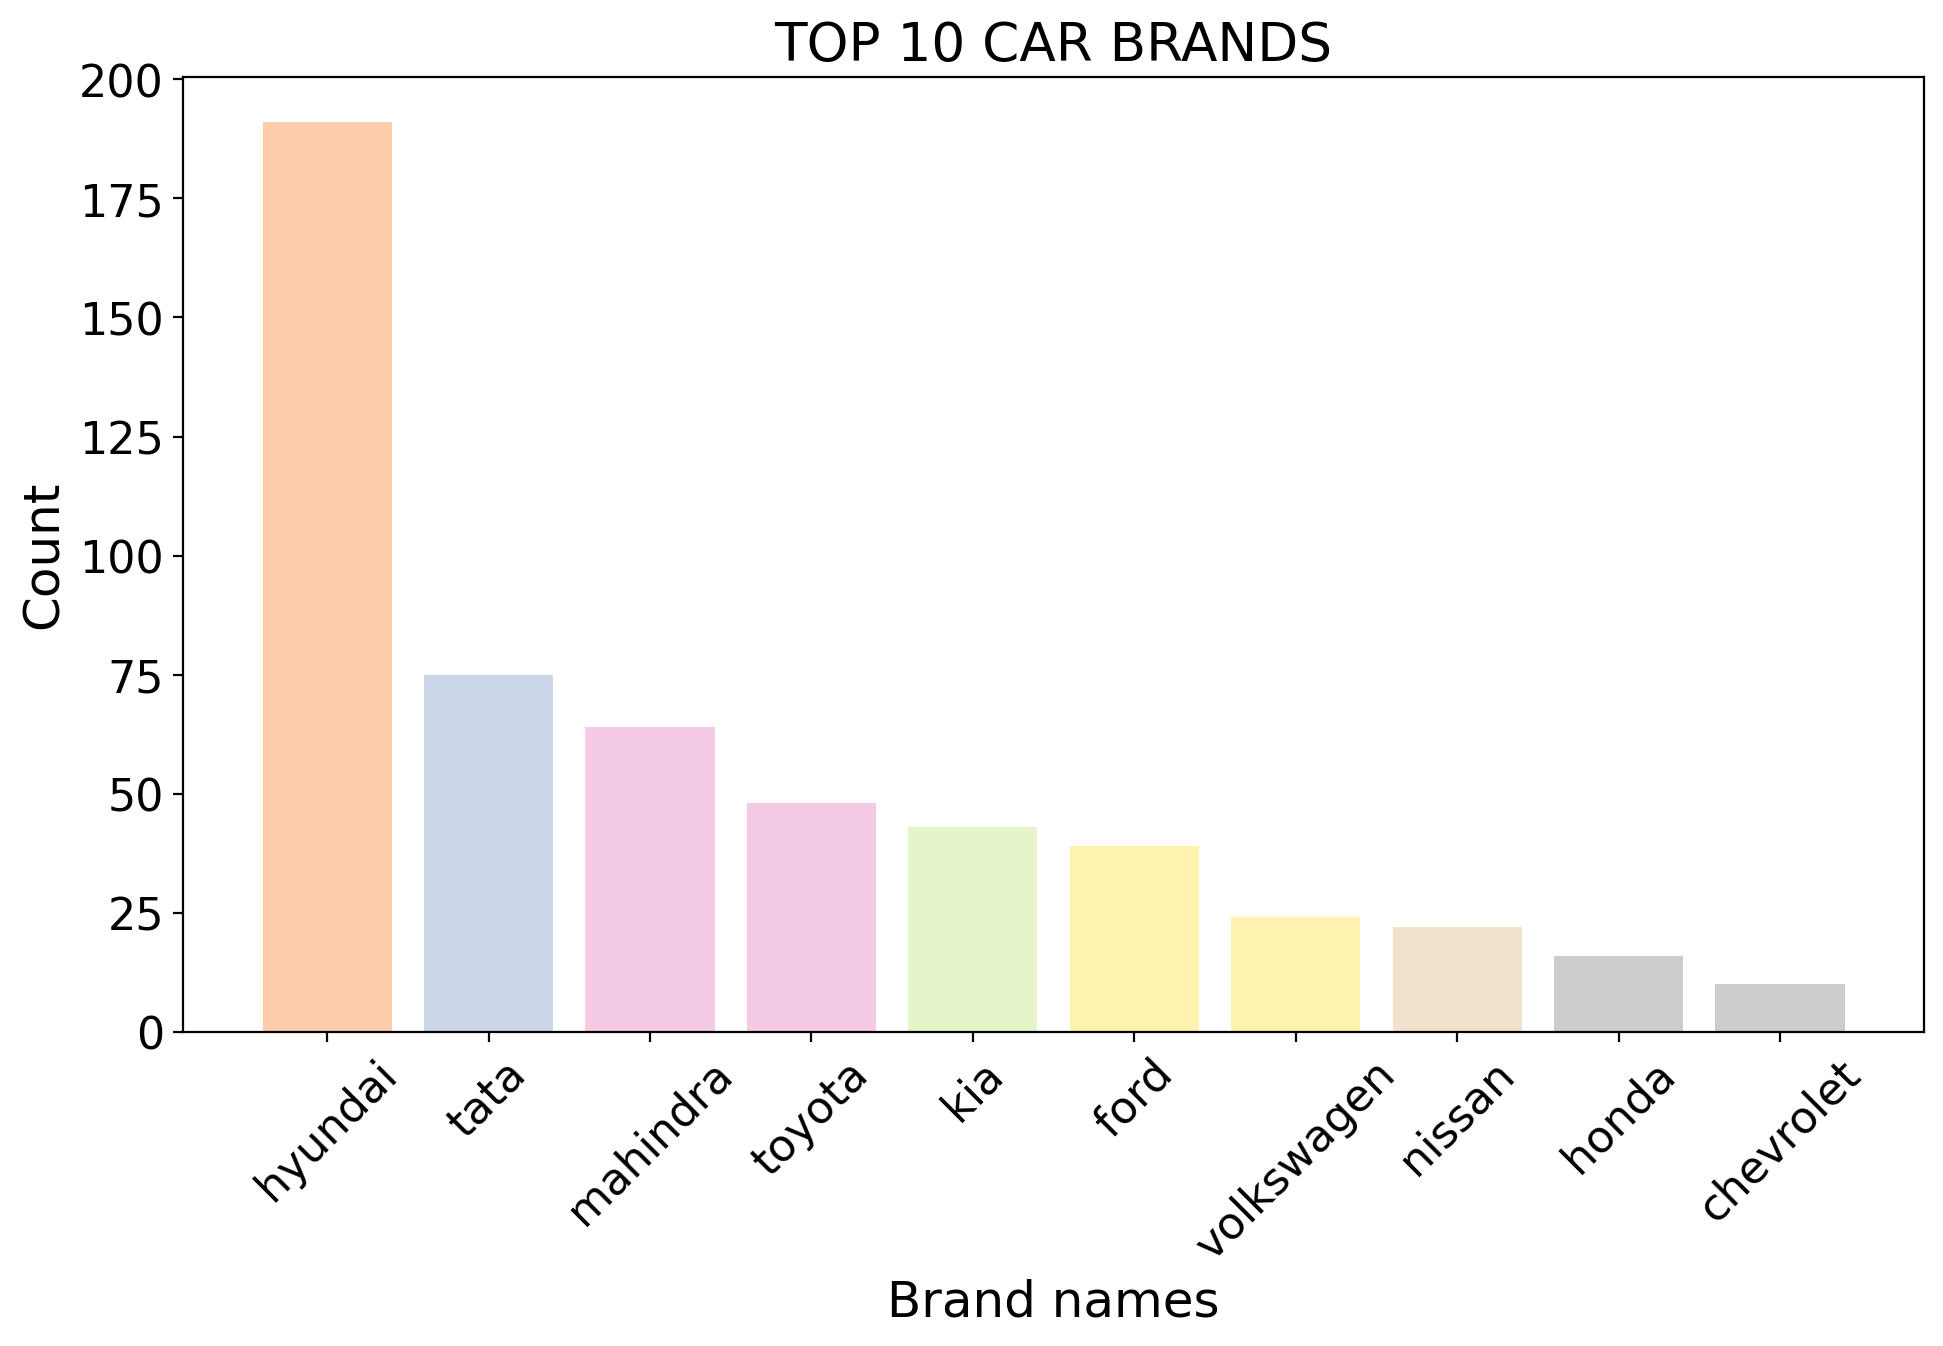

In [ ]:
#Calculating top 10 car brands in the dataset and plotting the data in a bar plot
top_brands_series = df['brand'].value_counts().sort_values(ascending=False).head(10)
x = top_brands_series.index
y = top_brands_series.values
colors = plt.cm.Pastel2(np.linspace(0.2, 1, len(x)))
plt.figure(figsize=(10, 7))
plt.rcParams['font.size'] = 16
plt.bar(x, y, color = colors)
plt.title('TOP 10 CAR BRANDS')
plt.xticks(rotation=45)
plt.xlabel('Brand names', fontdict={'fontsize': 18})
plt.ylabel('Count', fontdict={'fontsize': 18})
plt.tight_layout()
plt.show()

In [ ]:
#Considering the most common car colours only. ALso filling the NaN values with 'Unknown'.
df['colour'] = df['colour'].fillna('Unknown')
def sort_colour(shade):
  if 'black' in shade:
    return 'black'
  elif 'white' in shade:
    return 'white'
  elif 'silver' in shade or 'grey' in shade:
    return 'silver'
  elif 'blue' in shade:
    return 'blue'
  elif 'red' in shade:
    return 'red'
  elif 'green' in shade:
    return 'green'
  elif 'yellow' in shade:
    return 'yellow'
  elif 'brown' in shade:
    return 'brown'


df['colour'] = df['colour'].apply(sort_colour)

**5. Car Colour Distribution**

The car colour distribution plot shows popular cars in 8 common colors.
Silver is the most common color, followed by white. Blue and red follow behind, while colors like black, brown, green, and yellow are much less common. It is observed that the neutral car colours are more listed.

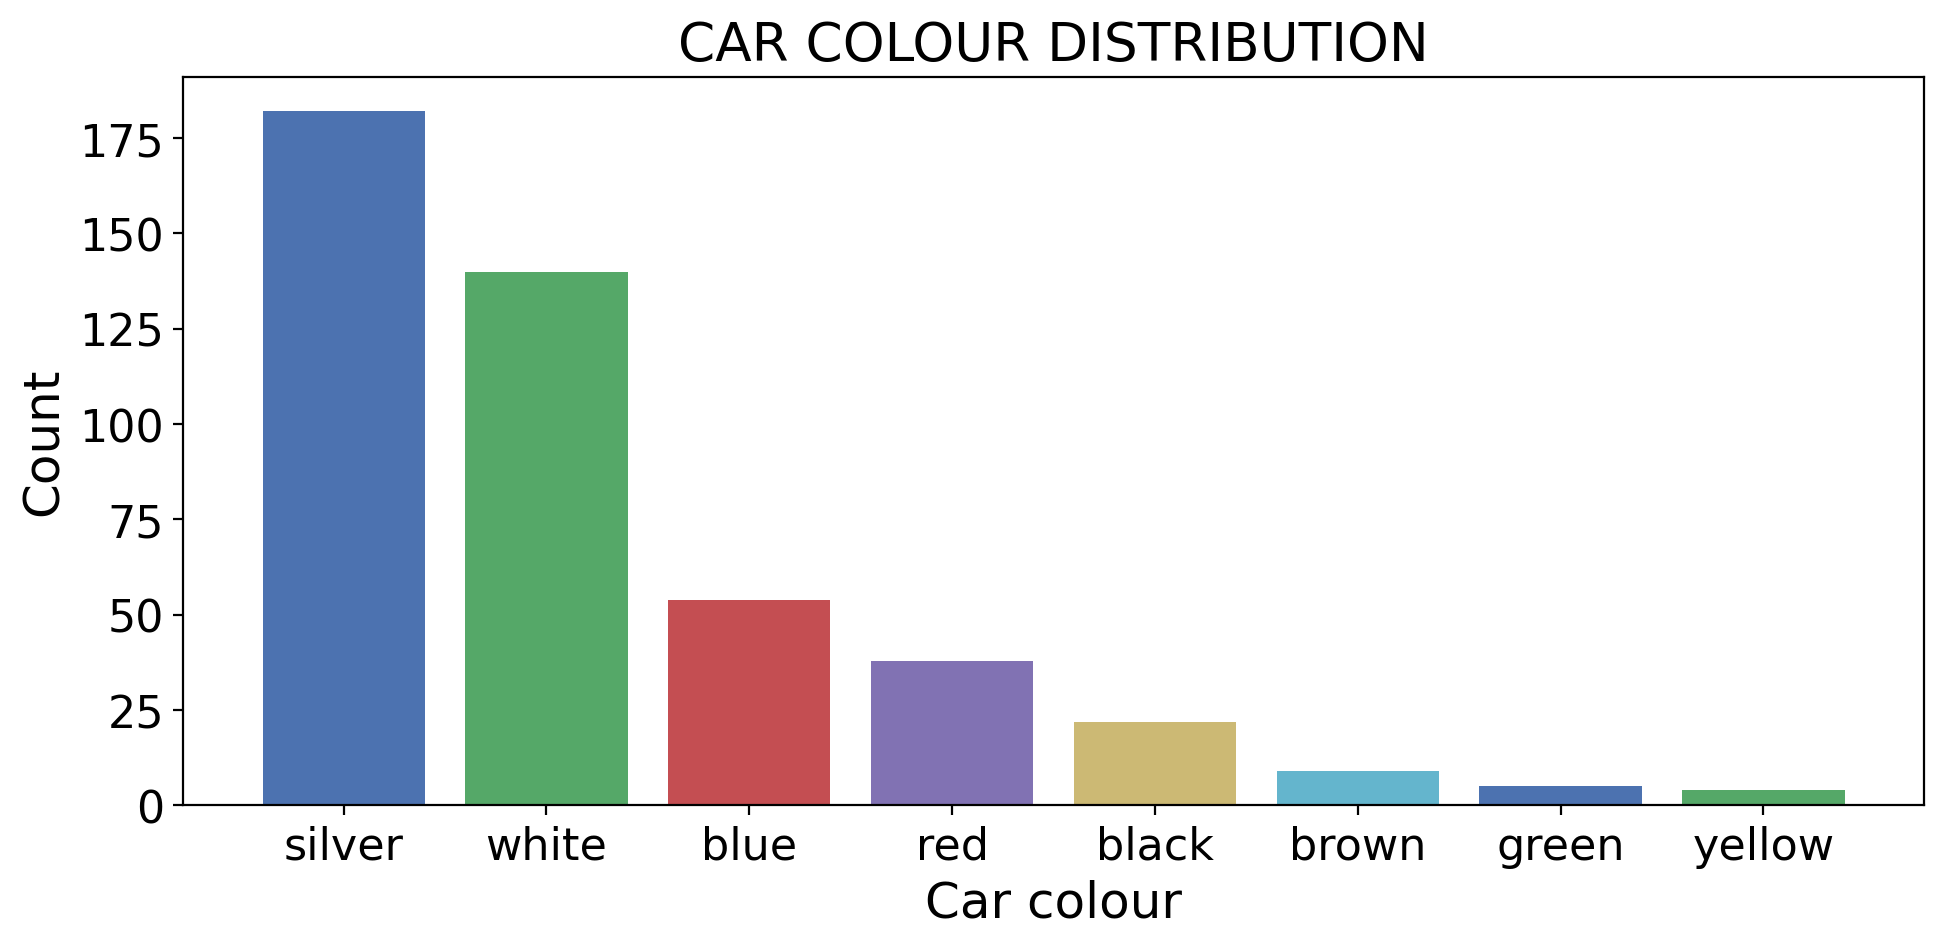

In [ ]:
#Plotting the most popular car colour in a bar graph.
count = df['colour'].value_counts()
bar_colours = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#64B5CD"]
x = count.index
y = count.values
plt.figure(figsize=(10,5))
plt.rcParams['font.size'] = 16
plt.bar(x, y, color = bar_colours)
plt.title('CAR COLOUR DISTRIBUTION')
plt.xlabel('Car colour', fontdict={'fontsize': 18})
plt.ylabel('Count', fontdict={'fontsize': 18})
plt.tight_layout()
plt.show()

**6. Price vs. Make Year Scatter Plot**

The Price vs make year scatter plot shows the relationship between a car's price and its manufacturing year.
Most of the newer cars i.e. cars manufactured during around 2010 to 2022 cluster toward the higher price range, while older cars generally appear at the lower end. The plot shows that newer models tend to cost more.

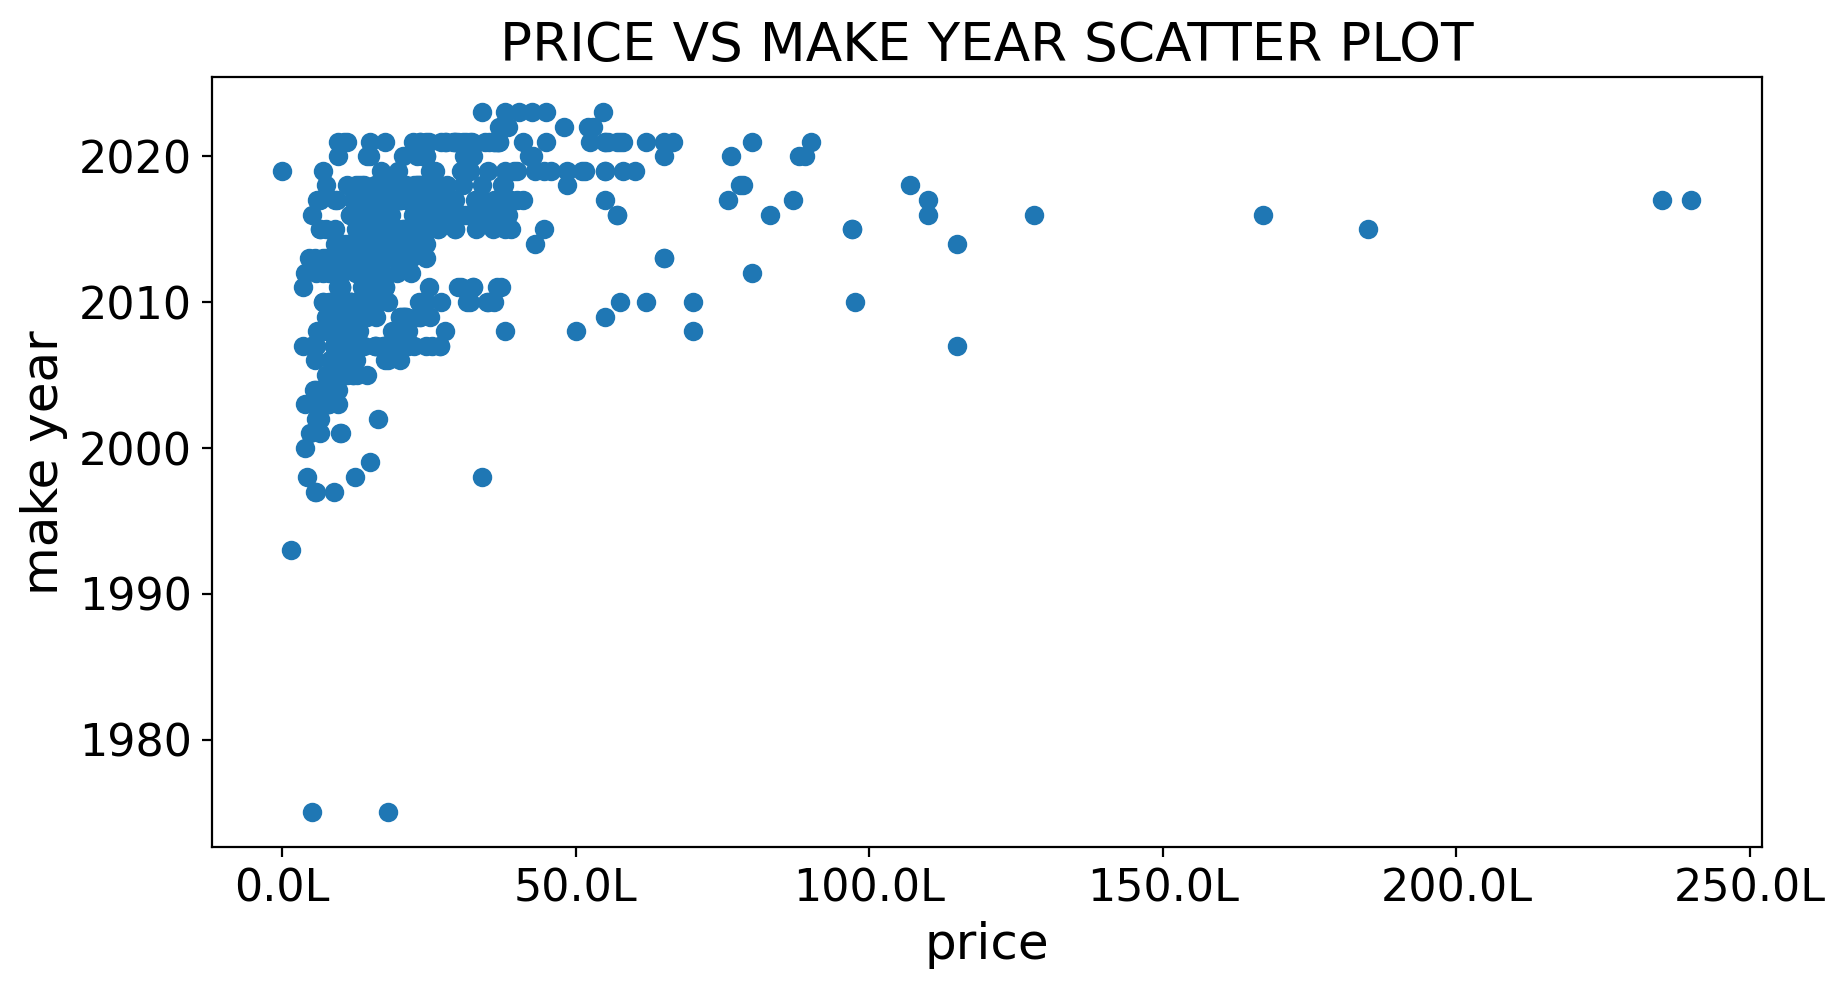

In [ ]:
#Showing the variation of price of the car with make year
x = df['price']
y = df['make_year']
plt.figure(figsize=(10,5))
plt.rcParams['font.size'] = 16
plt.title('PRICE VS MAKE YEAR SCATTER PLOT')
plt.scatter(x, y)
plt.xlabel('price', fontdict={'fontsize': 18})
plt.ylabel('make year', fontdict={'fontsize': 18})
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1_00_000:.1f}L'))
plt.show()

**7. Car Age vs. Mileage Scatter Plot**

The Car Age vs. Mileage Scatter Plot shows how car age relates to mileage.
Most of the younger cars have low mileage, while some older cars show higher mileage. There are also many cars with very low mileage regardless of age. This suggests the dataset includes a mix of lightly used and heavily used vehicles.

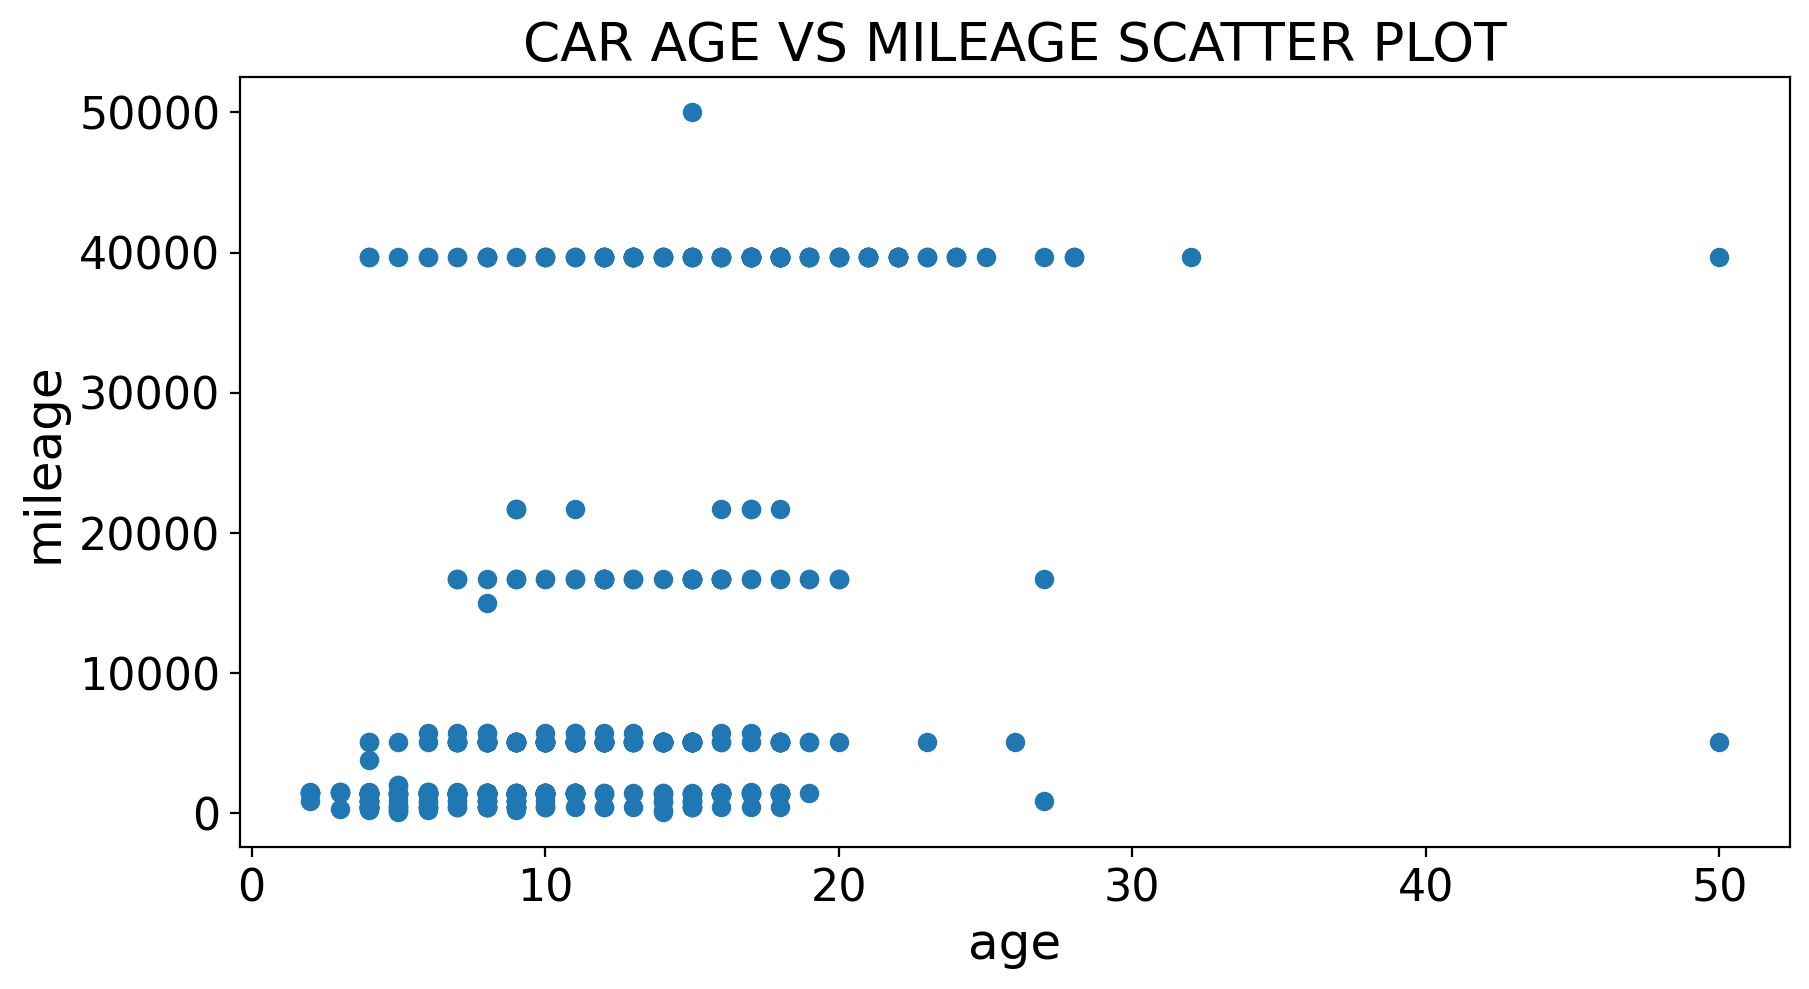

In [ ]:
#Showing the change in the mileage of the car with car age
age = df['car_age']
mil = df['mileage']
plt.figure(figsize=(10,5))
plt.rcParams['font.size'] = 16
plt.title('CAR AGE VS MILEAGE SCATTER PLOT')
plt.scatter(age, mil)
plt.xlabel('age', fontdict={'fontsize': 18})
plt.ylabel('mileage', fontdict={'fontsize': 18})
plt.show()

**8. Average Price of Top 10 Car Brands**

The line plot shows the average price of the top 10 brands in the dataset.
Each point represents the averege price for a brand. As we move down the list, the prices generally increase. Chevrolet has the lowest average price, while Toyota has the highest price. It shows how different brands compare in terms of pricing.

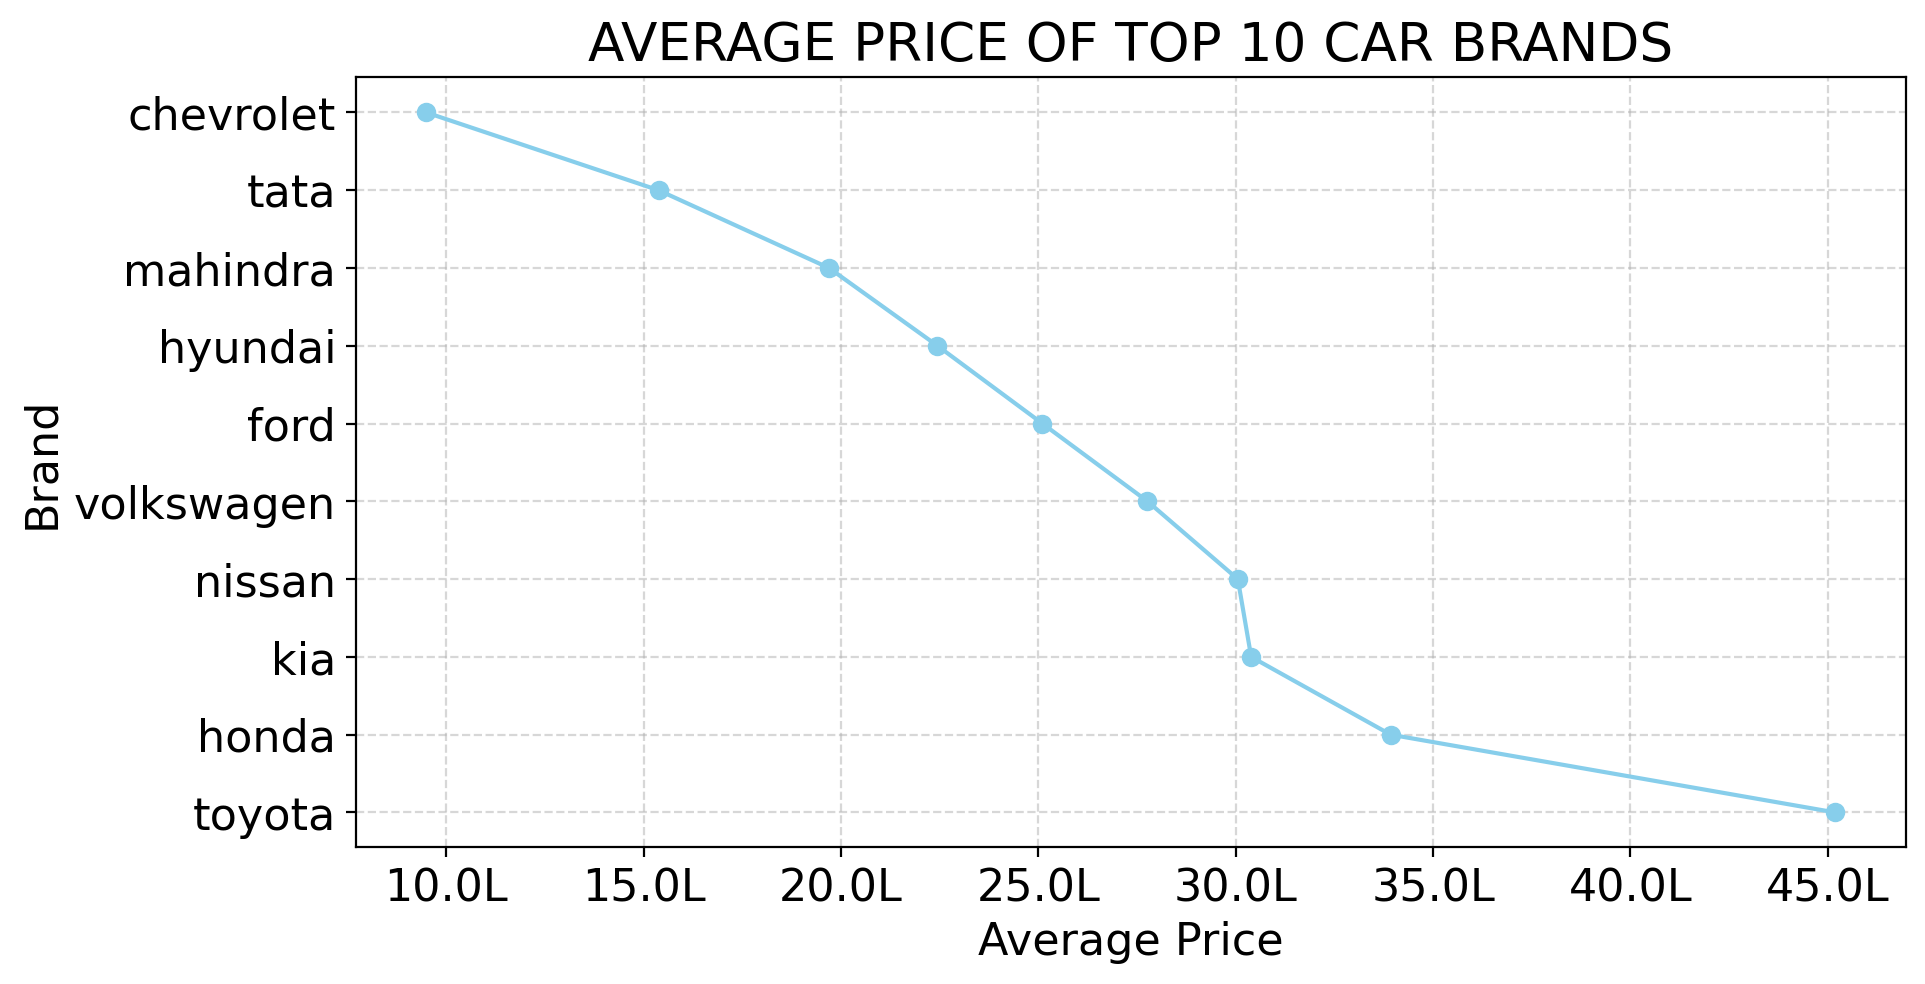

In [ ]:
#Calculating the average price of top 10 car brands
top_brands = df['brand'].value_counts().head(10).index
avg_price= df[df['brand'].isin(top_brands)].groupby('brand')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.plot(avg_price.values, avg_price.index, marker='o', linestyle='-', color='skyblue')
plt.xlabel("Average Price")
plt.ylabel('Brand')
plt.title("AVERAGE PRICE OF TOP 10 CAR BRANDS")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1_00_000:.1f}L'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100


**9. Price vs Brand Boxplot**

The boxplot shows the price range and price variation for each brand.
Each box shows how the prices are spread—from the cheaper models to the more expensive ones.The dots on the right are outliers, meaning those cars are unusually expensive compared to the rest of the brand's listings.

The plot shows brands have a tight, consistent price range like Chevrolet and Honda, and which ones have a wide spread with many high-price outliers like Toyota, Kia, and Hyundai. It helps to compare how stable or varied each brand's pricing is.

<Figure size 3600x2000 with 0 Axes>

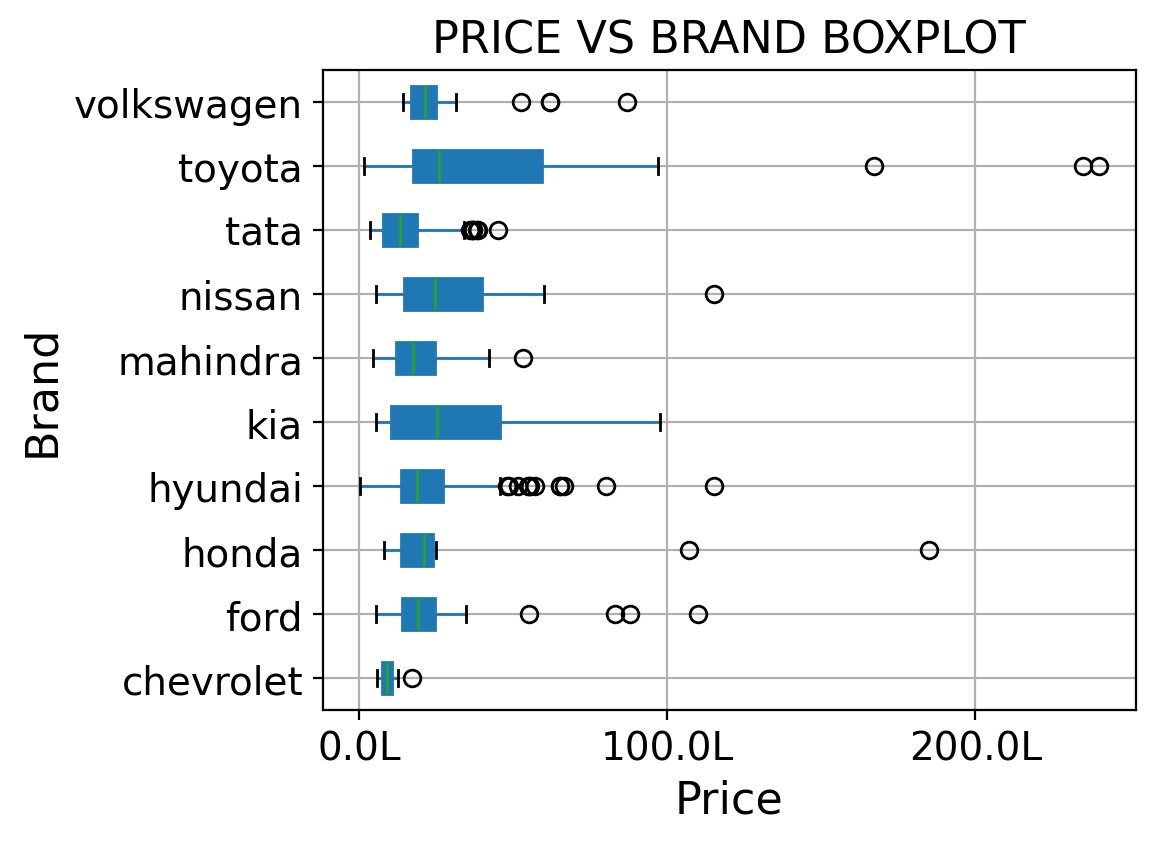

In [ ]:
top_brands = df['brand'].value_counts().head(10).index
df_top = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(36, 20))
plt.rcParams['font.size'] = 18
df_top.boxplot(
    column='price',
    by='brand',
    vert=False,
    patch_artist=True
)
plt.title("PRICE VS BRAND BOXPLOT", fontsize=16)
plt.suptitle("")
plt.xlabel("Price", fontsize=16)
plt.ylabel("Brand", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/100000:.1f}L")
)
plt.tight_layout()
plt.show()